## Decision Tree

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
titanic_data = pd.read_csv('Titanic-Dataset.csv') 
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
#convert categorical data into numeric values 

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
titanic_data['Sex'] = le.fit_transform(titanic_data['Sex'])
titanic_data['Embarked'] = le.fit_transform(titanic_data['Embarked'])
titanic_data['Cabin'] = le.fit_transform(titanic_data['Cabin'])
titanic_data['Ticket'] = le.fit_transform(titanic_data['Ticket'])

In [6]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,523,7.2500,147,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,596,71.2833,81,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,669,7.9250,147,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,49,53.1000,55,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,472,8.0500,147,2


In [7]:
#count of missing values in each column 

In [8]:
missing_values = titanic_data.isnull().sum()
print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         0
dtype: int64


In [9]:
# Fill missing values in 'Age' with the mean value

In [10]:
titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace=True)

In [11]:
missing_values = titanic_data.isnull().sum()
print(missing_values)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [12]:
titanic_data.drop(['Name'], axis=1, inplace=True) 

In [13]:
print(titanic_data.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Sex              int32
Age            float64
SibSp            int64
Parch            int64
Ticket           int32
Fare           float64
Cabin            int32
Embarked         int32
dtype: object


In [14]:
X = titanic_data.drop('Survived', axis=1)
y = titanic_data['Survived']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
treemodel = DecisionTreeClassifier(max_depth=4, random_state=42)
treemodel.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [17]:
y_pred = treemodel.predict(X_test)

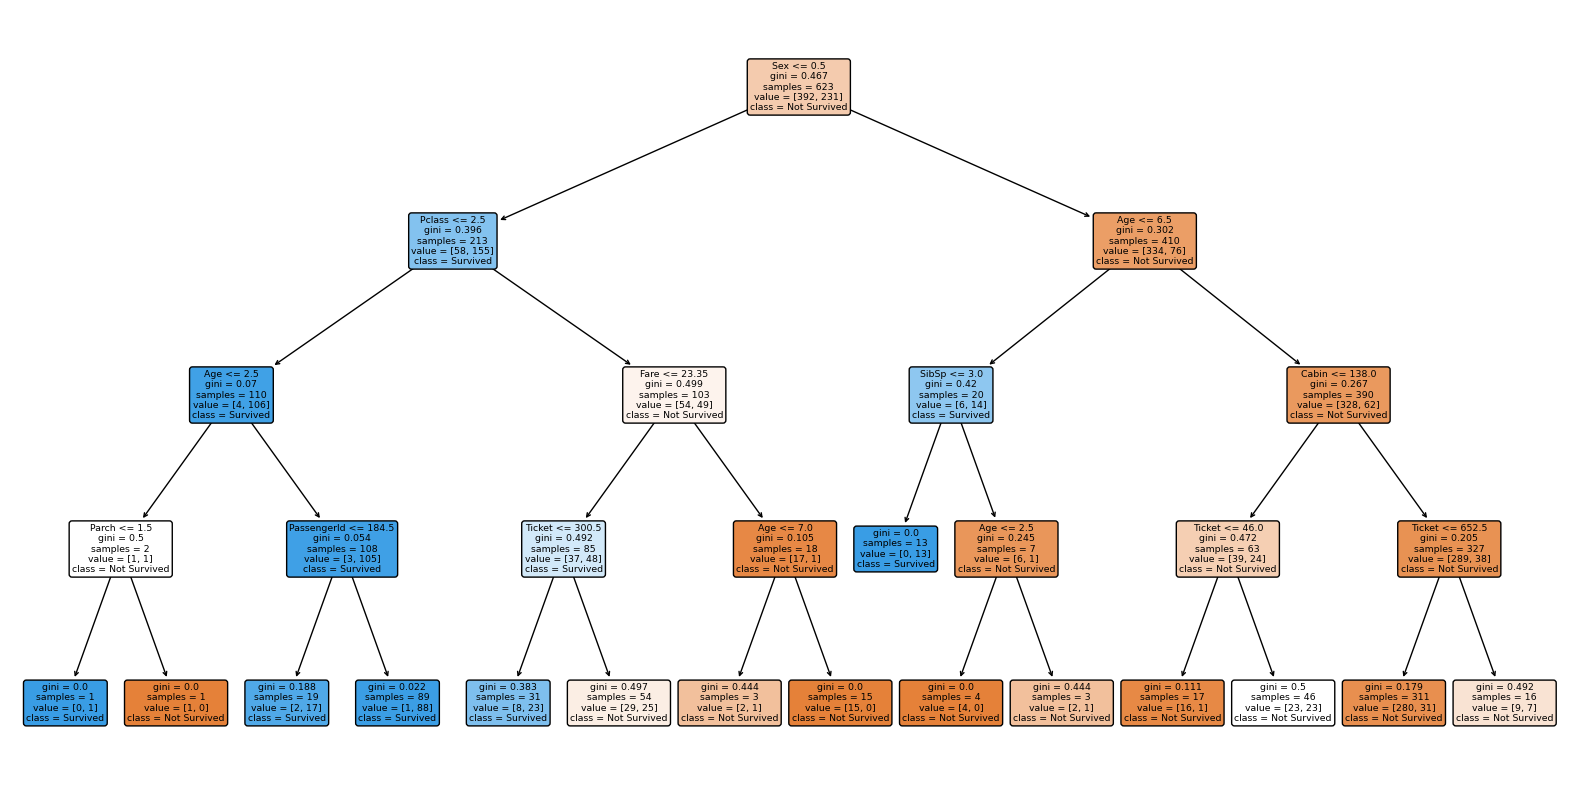

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(treemodel,feature_names=X.columns,class_names=['Not Survived', 'Survived'],filled=True,rounded=True)
plt.show()

In [19]:
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 78.73%

Confusion Matrix:
 [[145  12]
 [ 45  66]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.92      0.84       157
           1       0.85      0.59      0.70       111

    accuracy                           0.79       268
   macro avg       0.80      0.76      0.77       268
weighted avg       0.80      0.79      0.78       268



# KNN:

In [20]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [21]:
titanic_dataset = pd.read_csv('Titanic-Dataset.csv') 

In [22]:
titanic_dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Handle Missing Data:

Columns like Age, Cabin, and Embarked have missing values.

In [23]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # For numerical columns like Age and Fare
titanic_dataset['Age'] = imputer.fit_transform(titanic_dataset[['Age']])

In [24]:
# Encode categorical variables like 'Sex' and 'Embarked'
label_encoder = LabelEncoder()
titanic_dataset['Sex'] = label_encoder.fit_transform(titanic_dataset['Sex'])
titanic_dataset['Embarked'] = label_encoder.fit_transform(titanic_dataset['Embarked'])

In [25]:
# Handle missing values
imputer = SimpleImputer(strategy='mean')  
# For numerical columns like Age and Fare
titanic_dataset['Age'] = imputer.fit_transform(titanic_dataset[['Age']])

In [26]:
# Handle missing values
imputer = SimpleImputer(strategy='mean')  
# For numerical columns like Age and Fare
titanic_dataset['Fare'] = imputer.fit_transform(titanic_dataset[['Fare']])

In [27]:
titanic_dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,211536,13.0000,NaN,2
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,112053,30.0000,B42,2
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,W./C. 6607,23.4500,NaN,2
889,890,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,111369,30.0000,C148,0


### Feature Selection:

We'll select relevant features like Pclass, Sex, Age, SibSp, Parch, Fare, and Embarked.
The Cabin column will likely be dropped due to many missing values.

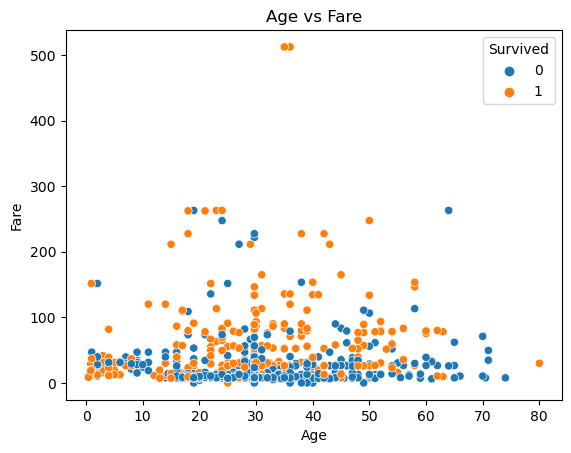

In [28]:
sns.scatterplot(data=titanic_dataset, x='Age', y='Fare', hue='Survived')
plt.title('Age vs Fare')
plt.show()

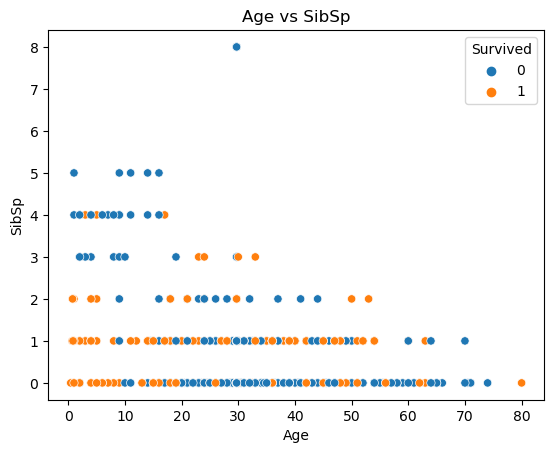

In [29]:
sns.scatterplot(data=titanic_dataset, x='Age', y='SibSp', hue='Survived')
plt.title('Age vs SibSp')
plt.show()

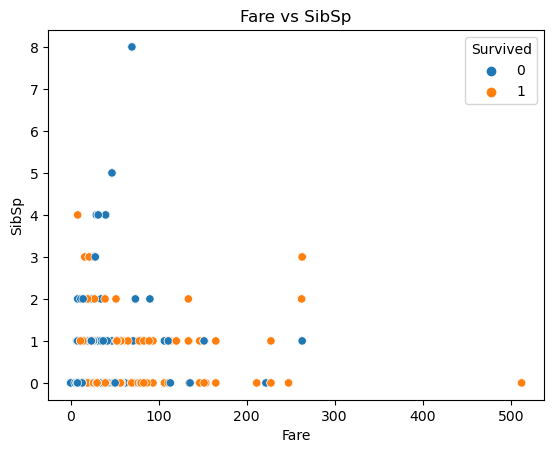

In [30]:
sns.scatterplot(data=titanic_dataset, x='Fare', y='SibSp', hue='Survived')
plt.title('Fare vs SibSp')
plt.show()

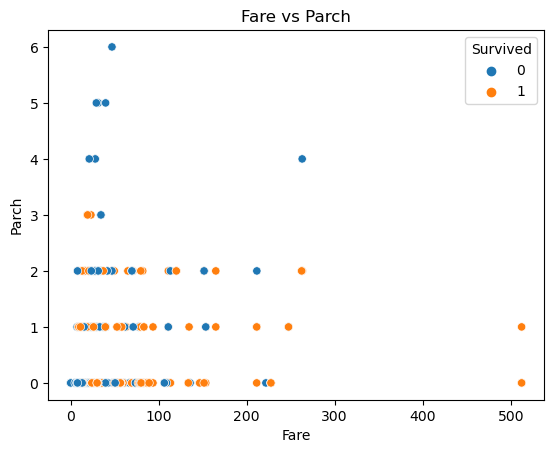

In [31]:
sns.scatterplot(data=titanic_dataset, x='Fare', y='Parch', hue='Survived')
plt.title('Fare vs Parch')
plt.show()

### Splitting the Dataset:

We'll split the dataset into training and testing sets to evaluate model performance.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    titanic_dataset[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']], titanic_dataset['Survived'], random_state=0)

### Applying KNN:

We’ll implement the KNN algorithm using the KNeighborsClassifier from scikit-learn.

In [33]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [34]:
y_pred = knn.predict(X_test)

### Model Evaluation:

Evaluate the performance using metrics like accuracy, precision, recall, or confusion matrix.

In [35]:
print("Test set score: {:.2f}".format(knn.score(X_test, y_test)))

Test set score: 0.70


In [36]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[107  32]
 [ 35  49]]


In [37]:
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       139
           1       0.60      0.58      0.59        84

    accuracy                           0.70       223
   macro avg       0.68      0.68      0.68       223
weighted avg       0.70      0.70      0.70       223



In [38]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy*100)

Accuracy: 69.95515695067265


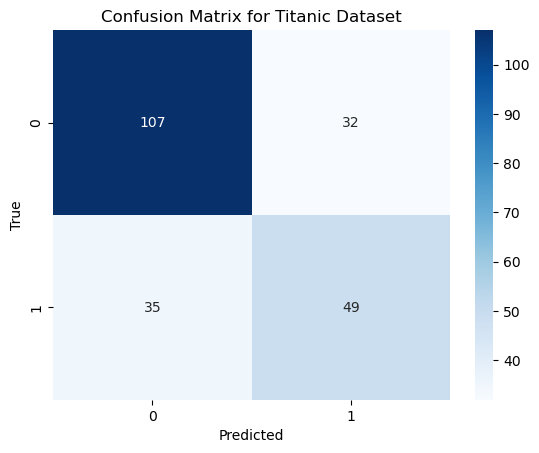

In [39]:
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="g")
plt.title("Confusion Matrix for Titanic Dataset")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()